### Display MTEB results for TF-IDF models with varying vocabs
MTEB results are saved in .json files, one for each task. 
This notebook aggregates the results for multiple tasks and multiple TF-IDF models.
The models differ in the way that the vocab used for embedding is constructed.
There are 4 parameters that are varied here:
- maxfeatures: this limits the number of entries the vocabulary has. Only the k most frequent words (highest term frrequency across the entire corpus) are used for the vocab.
- ngram_range: consider unigrams or bigrams or both
- max_df: When building the vocabulary ignore terms that have a document frequency strictly higher than the given threshold (corpus-specific stop words). The lower this gets, the more words are ignored. -> ignore words bc they are too frequent and thus don't carry much information
- min_df: When building the vocabulary ignore terms that have a document frequency strictly lower than the given threshold (cut-off). The higher this gets, the more words are ignored. -> ignore words bc they are weird outliers in the corpus

In [1]:
import mteb
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import regex as re
import os


### compare results for different vocab settings

In [2]:
data = {}
main_dir = "../MTEB/vocab_test_results"


# Traverse folders and subfolders
for (root, dirs, files) in os.walk(main_dir):
    # Identify model version from the folder structure (this requires some hacking)
    directory = os.path.basename(root)
    if "ngram" in directory:
        vocab_version = directory
        #print(vocab_version)
        
    for file in files:
        # Skip unwanted files
        if file in {"model_meta.json"} or not file.endswith('.json'):
            continue
            
        file_path = os.path.join(root, file)
        #print(file_path)
        try:
            # Read JSON and extract necessary fields
            with open(file_path, 'r') as f:
                json_data = json.load(f)
                task_name = json_data.get("task_name")
                main_score = json_data.get("scores", {}).get("test", {})[0]["main_score"]
                main_score = round(main_score*100, 2)
                    
                if task_name and main_score is not None:
                    if task_name not in data:
                        data[task_name] = {}
                    data[task_name][vocab_version] = main_score
        except (json.JSONDecodeError, KeyError):
            print(f"Error parsing file: {file_path}")

In [3]:
df = pd.DataFrame.from_dict(data, orient='index')
df.index.name = "task_name"
df["task_types"] = [mteb.get_task(task).metadata.type for task in df.index]
df

,ngram_1-1_maxdf_0-4_mindf_0-01_maxfeatures_None,ngram_2-2_maxdf_0-1_mindf_0-05_maxfeatures_None,ngram_1-2_maxdf_0-4_mindf_0-01_maxfeatures_None,ngram_1-1_maxdf_0-6_mindf_0-1_maxfeatures_None,ngram_2-2_maxdf_1-0_mindf_0-05_maxfeatures_None,ngram_2-2_maxdf_0-4_mindf_0-05_maxfeatures_None,ngram_1-1_maxdf_0-1_mindf_0-01_maxfeatures_None,ngram_1-2_maxdf_1-0_mindf_0-01_maxfeatures_None,ngram_1-2_maxdf_0-8_mindf_0-02_maxfeatures_None,ngram_1-1_maxdf_1-0_mindf_0-01_maxfeatures_None,...,ngram_1-1_maxdf_0-05_mindf_1-0_maxfeatures_None,ngram_2-2_maxdf_0-2_mindf_0-05_maxfeatures_None,ngram_1-1_maxdf_0-8_mindf_0-05_maxfeatures_None,ngram_1-2_maxdf_0-2_mindf_1-0_maxfeatures_None,ngram_2-2_maxdf_0-05_mindf_0-02_maxfeatures_None,ngram_1-2_maxdf_0-02_mindf_0-01_maxfeatures_None,ngram_2-2_maxdf_0-4_mindf_0-02_maxfeatures_None,ngram_1-2_maxdf_0-8_mindf_0-05_maxfeatures_None,ngram_1-2_maxdf_0-05_mindf_1-0_maxfeatures_None,task_types
task_name,,,,,,,,,,,,,,,,,,,,,
MedrxivClusteringP2P,28.82,0.00,28.82,22.69,0.00,0.00,28.44,29.00,27.89,29.00,...,30.73,0.00,26.10,30.33,0.00,23.78,0.00,26.10,30.73,Clustering
ArxivClusteringP2P,35.33,3.23,35.33,14.73,3.23,3.23,34.13,35.72,31.91,35.72,...,39.08,3.23,22.45,40.21,3.23,26.09,3.23,22.45,39.08,Clustering
MindSmallReranking,24.32,0.00,24.31,15.90,0.00,0.00,25.03,24.31,22.65,24.32,...,26.74,0.00,18.55,26.84,10.00,23.93,10.00,18.55,26.74,Reranking
SciDocsRR,31.39,0.00,31.39,0.00,0.00,0.00,31.39,31.39,27.24,31.39,...,55.87,0.00,23.26,52.69,0.00,21.62,0.00,23.26,55.87,Reranking
ArguAna,30.94,0.00,30.94,3.75,0.00,0.00,32.39,30.00,22.79,30.00,...,41.33,0.00,10.79,43.85,0.00,13.60,0.00,10.79,41.33,Retrieval
STS15,48.65,NaN,48.61,22.85,NaN,NaN,44.64,48.63,43.61,48.65,...,48.34,NaN,36.54,52.61,NaN,30.27,NaN,36.55,48.33,STS
SCIDOCS,3.25,0.00,3.25,0.27,0.00,0.00,3.81,3.28,2.17,3.28,...,5.89,0.00,0.73,5.51,0.00,1.62,0.00,0.73,5.89,Retrieval
STS16,33.11,NaN,33.11,17.00,NaN,NaN,32.90,32.92,25.89,32.93,...,46.91,NaN,21.27,47.42,NaN,22.10,NaN,21.27,46.91,STS
RedditClusteringP2P,29.18,0.00,29.20,15.69,0.00,0.00,28.83,29.83,23.88,29.83,...,38.02,0.00,19.85,34.49,0.00,25.11,0.00,19.85,38.02,Clustering


#### Results for varying ngram range and maximum vocab size

In [20]:
ngram = ["1-1"]#, "1-2", "2-2"]
maxdf = ["1-0"]#["0-01", "0-02", "0-05", "0-1", "0-2", "1-0"]
mindf = ["1-0", "0-01", "0-02", "0-05", "0-1"]
maxfeatures = ["None"]#["1000", "2000", "5000", "10000", "None"]

vocab_versions = [f"ngram_{n}_maxdf_{ma}_mindf_{mi}_maxfeatures_{f}" for n in ngram for ma in maxdf for mi in mindf for f in maxfeatures]# if ma > mi]

if 'ngram_1-2_maxdf_0-8_mindf_0-1_maxfeatures_None' in vocab_versions:
    vocab_version = vocab_versions.remove('ngram_1-2_maxdf_0-8_mindf_0-1_maxfeatures_None')
if 'ngram_2-2_maxdf_0-8_mindf_0-1_maxfeatures_None' in vocab_versions:
    vocab_version = vocab_versions.remove('ngram_2-2_maxdf_0-8_mindf_0-1_maxfeatures_None')    


In [21]:
vocab_versions

['ngram_1-1_maxdf_1-0_mindf_1-0_maxfeatures_None',
 'ngram_1-1_maxdf_1-0_mindf_0-01_maxfeatures_None',
 'ngram_1-1_maxdf_1-0_mindf_0-02_maxfeatures_None',
 'ngram_1-1_maxdf_1-0_mindf_0-05_maxfeatures_None',
 'ngram_1-1_maxdf_1-0_mindf_0-1_maxfeatures_None']

In [22]:
df_subset = df[vocab_versions + ["task_types"]].sort_index().sort_values("task_types")
df_subset.to_latex(na_rep="-", float_format="%.2f")

'\\begin{tabular}{lrrrrrl}\n\\toprule\n & ngram_1-1_maxdf_1-0_mindf_1-0_maxfeatures_None & ngram_1-1_maxdf_1-0_mindf_0-01_maxfeatures_None & ngram_1-1_maxdf_1-0_mindf_0-02_maxfeatures_None & ngram_1-1_maxdf_1-0_mindf_0-05_maxfeatures_None & ngram_1-1_maxdf_1-0_mindf_0-1_maxfeatures_None & task_types \\\\\ntask_name &  &  &  &  &  &  \\\\\n\\midrule\nArxivClusteringP2P & 40.34 & 35.72 & 32.06 & 22.41 & 15.36 & Clustering \\\\\nBiorxivClusteringP2P & 33.93 & 31.66 & 29.72 & 25.56 & 16.89 & Clustering \\\\\nMedrxivClusteringP2P & 29.81 & 29.00 & 27.93 & 25.91 & 22.89 & Clustering \\\\\nRedditClusteringP2P & 34.53 & 29.83 & 24.18 & 19.85 & 16.23 & Clustering \\\\\nStackExchangeClusteringP2P & 34.18 & 33.05 & 31.80 & 28.02 & 23.24 & Clustering \\\\\nMindSmallReranking & 26.64 & 24.32 & 22.65 & 18.55 & 15.90 & Reranking \\\\\nSciDocsRR & 52.69 & 31.39 & 27.24 & 23.26 & 0.00 & Reranking \\\\\nArguAna & 41.56 & 30.00 & 22.66 & 10.78 & 3.67 & Retrieval \\\\\nSCIDOCS & 5.31 & 3.28 & 2.12 & 0.76 

In [23]:
# Reshape DataFrame for plotting
df_melted = df_subset.reset_index().melt(id_vars=['task_name', 'task_types'], var_name='version', value_name='score')

# add the ngram and maxfeature properties
maxfeat = [re.search(r'(\d+)$', v) for v in df_melted["version"]]
maxfeat = []
ng = []
mxdf = []
mndf = []

for v in df_melted["version"]:
    match1 = re.search(r'(\d+)$|None$', v)
    maxfeat += [str(match1.group(1))]

    match2 = re.findall(r'\d+-\d+', v)
    ng += [str(match2[0])]
    mxdf += [str(match2[1]).replace("-", ".")]
    mndf += [str(match2[2]).replace("-", ".")]

df_melted["maxfeatures"] = maxfeat
df_melted["ngram"] = ng
df_melted["maxdf"] = mxdf
df_melted["mindf"] = ["1" if m == "1.0" else m for m in mndf]

In [9]:
df_melted

,task_name,task_types,version,score,maxfeatures,ngram,maxdf,mindf
0,ArxivClusteringP2P,Clustering,ngram_1-1_maxdf_1-0_mindf_1-0_maxfeatures_None,40.34,None,1-1,1.0,1
1,BiorxivClusteringP2P,Clustering,ngram_1-1_maxdf_1-0_mindf_1-0_maxfeatures_None,33.93,None,1-1,1.0,1
2,MedrxivClusteringP2P,Clustering,ngram_1-1_maxdf_1-0_mindf_1-0_maxfeatures_None,29.81,None,1-1,1.0,1
3,RedditClusteringP2P,Clustering,ngram_1-1_maxdf_1-0_mindf_1-0_maxfeatures_None,34.53,None,1-1,1.0,1
4,StackExchangeClusteringP2P,Clustering,ngram_1-1_maxdf_1-0_mindf_1-0_maxfeatures_None,34.18,None,1-1,1.0,1
5,MindSmallReranking,Reranking,ngram_1-1_maxdf_1-0_mindf_1-0_maxfeatures_None,26.64,None,1-1,1.0,1
6,SciDocsRR,Reranking,ngram_1-1_maxdf_1-0_mindf_1-0_maxfeatures_None,52.69,None,1-1,1.0,1
7,ArguAna,Retrieval,ngram_1-1_maxdf_1-0_mindf_1-0_maxfeatures_None,41.56,None,1-1,1.0,1
8,SCIDOCS,Retrieval,ngram_1-1_maxdf_1-0_mindf_1-0_maxfeatures_None,5.31,None,1-1,1.0,1
9,STS15,STS,ngram_1-1_maxdf_1-0_mindf_1-0_maxfeatures_None,52.65,None,1-1,1.0,1


In [24]:
# Assign unique x positions for tasks
task_order = {"ArxivClusteringP2P": 1,
              "BiorxivClusteringP2P": 2,
              "MedrxivClusteringP2P": 3,
              "RedditClusteringP2P": 4,
              "StackExchangeClusteringP2P": 5,
              "MindSmallReranking": 6,
              "SciDocsRR": 7,
              "ArguAna": 8,
              "SCIDOCS": 9,
              "STS15": 10,
              "STS16": 11,
              "STSBenchmark": 12
              }

df_melted["x_pos"] = [task_order[t] for t in df_melted["task_name"]]

In [25]:
# create color matching for maxfeatures
names = ["1000", "2000", "5000", "10000", "None"]
colors_dict = dict(zip(names, sns.color_palette('colorblind', len(names))))

# color matching for maxdf / mindf 
names = ["0.01", "0.02", "0.05", "0.1", "0.2", "1.0"]
colors_dict_maxdf = dict(zip(names, sns.color_palette('colorblind', len(names))))
names = ["1", "0.01", "0.02", "0.05", "0.1"]
colors_dict_mindf = dict(zip(names, sns.color_palette('colorblind', len(names))))

# create opacity matching for ngrams
opacity_dict = dict(zip(["1-1", "1-2", "2-2"], [1.0, 0.66, 0.33]))


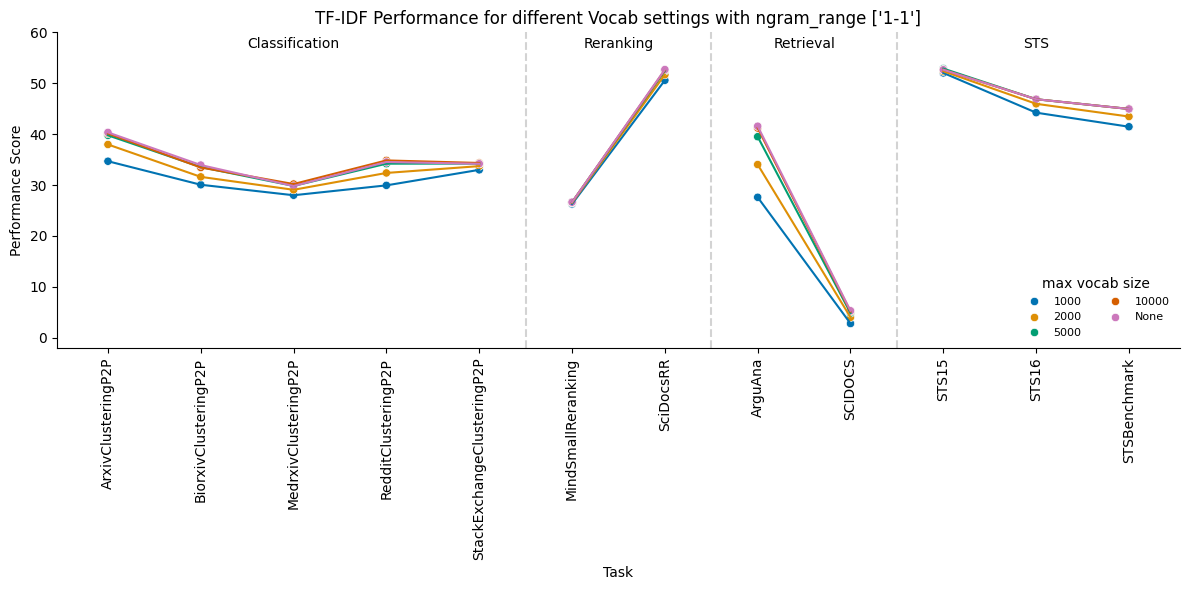

In [11]:
# single plot without ngram opacity
fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(data=df_melted, x='x_pos', y='score', hue='maxfeatures', palette=colors_dict)

# Draw lines connecting tasks within the same category for each model
for model in df_melted['version'].unique():
    subset = df_melted[df_melted['version'] == model]
    for category in subset['task_types'].unique():
        category_subset = subset[subset['task_types'] == category]
        category_subset_sorted = category_subset.sort_values("x_pos")
        sns.lineplot(data=category_subset_sorted, x='x_pos', y='score', hue='maxfeatures', palette=colors_dict, legend=False)

# add task type text
tasks = ["Classification", "Reranking", "Retrieval", "STS"]
placement = [3, 6.5, 8.5, 11]
for task, place in zip(tasks, placement):
    plt.text(place, 59, task, horizontalalignment = "center", verticalalignment = "top")
# task type boundaries
boundaries = [0.5, 5.5, 7.5, 9.5, 12.5]
for i in range(1, len(boundaries)-1):
    plt.axvline(boundaries[i], linestyle = "dashed", color = "lightgrey")
    


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend(loc = "lower right", title="max vocab size", frameon=False, prop={'size': 8}, ncol=2)
plt.title(f'TF-IDF Performance for different Vocab settings with ngram_range {ngram}')
plt.xlabel('Task')
plt.ylabel('Performance Score')
plt.ylim(-2,60)
plt.xticks(range(1,13), labels=list(task_order.keys()), rotation=90)
plt.tight_layout()
plt.savefig("../img/tfidf_vocab_maxfeatures_single.png")

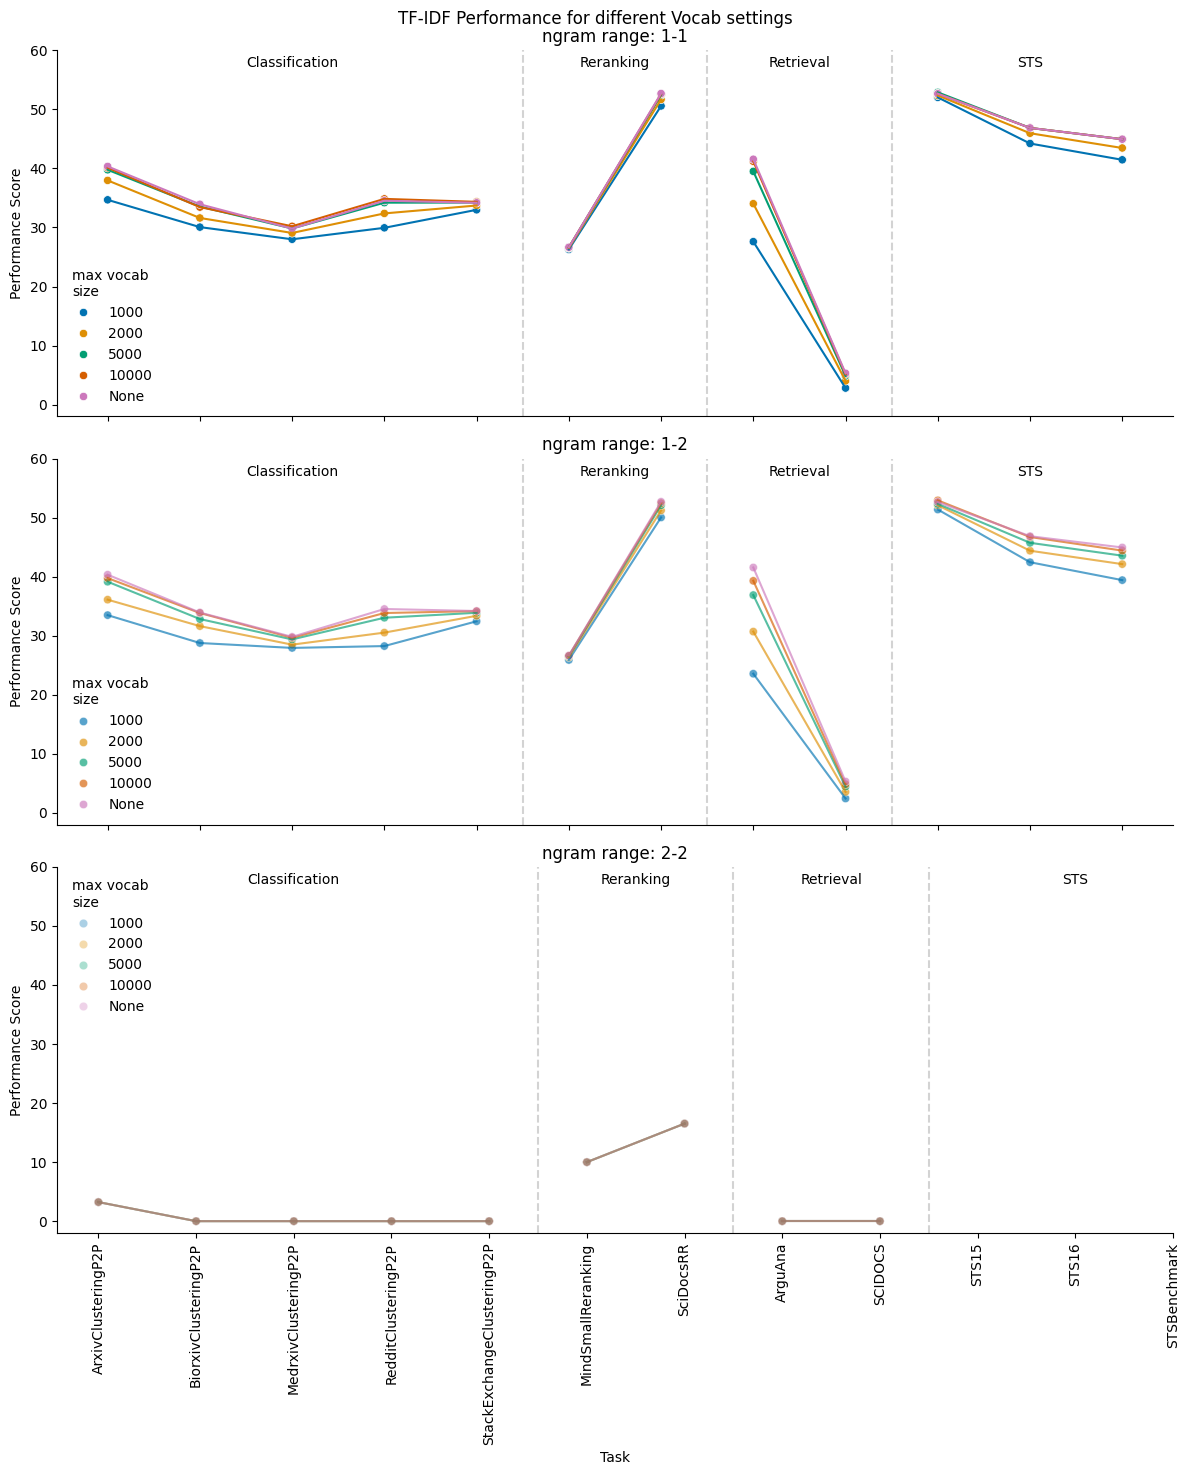

In [ ]:
fig, axs = plt.subplots(len(ngram), figsize=(12, len(ngram)*5))

for i, n in enumerate(ngram):
    if len(ngram) == 1:
        ax = axs
    else:
        ax = axs[i]
    df_ngram = df_melted[df_melted['ngram'] == n]
    sns.scatterplot(data=df_ngram, x='x_pos', y='score', hue='maxfeatures', 
                    palette=colors_dict, alpha=opacity_dict[n], ax=ax)

    # Draw lines connecting tasks within the same category for each model
    for model in df_ngram['version'].unique():
        subset = df_ngram[df_ngram['version'] == model]
        for category in subset['task_types'].unique():
            category_subset = subset[subset['task_types'] == category]
            category_subset_sorted = category_subset.sort_values("x_pos")
            sns.lineplot(data=category_subset_sorted, x='x_pos', y='score', hue='maxfeatures', 
                         palette=colors_dict, alpha=opacity_dict[n], legend=False, ax=ax)
    
    # add task type text
    tasks = ["Classification", "Reranking", "Retrieval", "STS"]
    placement = [3, 6.5, 8.5, 11]
    for task, place in zip(tasks, placement):
        ax.text(place, 59, task, horizontalalignment = "center", verticalalignment = "top")
    # task type boundaries
    boundaries = [0.5, 5.5, 7.5, 9.5, 12.5]
    for j in range(1, len(boundaries)-1):
        ax.axvline(boundaries[j], linestyle = "dashed", color = "lightgrey")
    
    # design stuff
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.legend(title="max vocab\nsize", frameon=False)
    ax.set_ylabel('Performance Score')
    ax.set_ylim(-2, 60)

    ax.set_title(f"ngram range: {n}")

    if i == len(ngram)-1: #lowest plot
        ax.set_xticks(range(1,13), labels=list(task_order.keys()), rotation=90)
        ax.set_xlabel('Task')
    else:
        ax.set_xticks(range(1,13), labels=[])
        ax.set_xlabel(None)



plt.suptitle('TF-IDF Performance for different Vocab settings')
plt.tight_layout()
plt.savefig("../img/tfidf_vocab_maxfeatures.png")

/var/folders/bd/rr8tbyms7wn9f6zw11rfsq_40000gn/T/ipykernel_48828/3546369709.py:26: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = df_ngram[df_mf['version'] == model]
/var/folders/bd/rr8tbyms7wn9f6zw11rfsq_40000gn/T/ipykernel_48828/3546369709.py:26: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = df_ngram[df_mf['version'] == model]
/var/folders/bd/rr8tbyms7wn9f6zw11rfsq_40000gn/T/ipykernel_48828/3546369709.py:26: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = df_ngram[df_mf['version'] == model]
/var/folders/bd/rr8tbyms7wn9f6zw11rfsq_40000gn/T/ipykernel_48828/3546369709.py:26: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = df_ngram[df_mf['version'] == model]
/var/folders/bd/rr8tbyms7wn9f6zw11rfsq_40000gn/T/ipykernel_48828/3546369709.py:26: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  subset = df_ngr

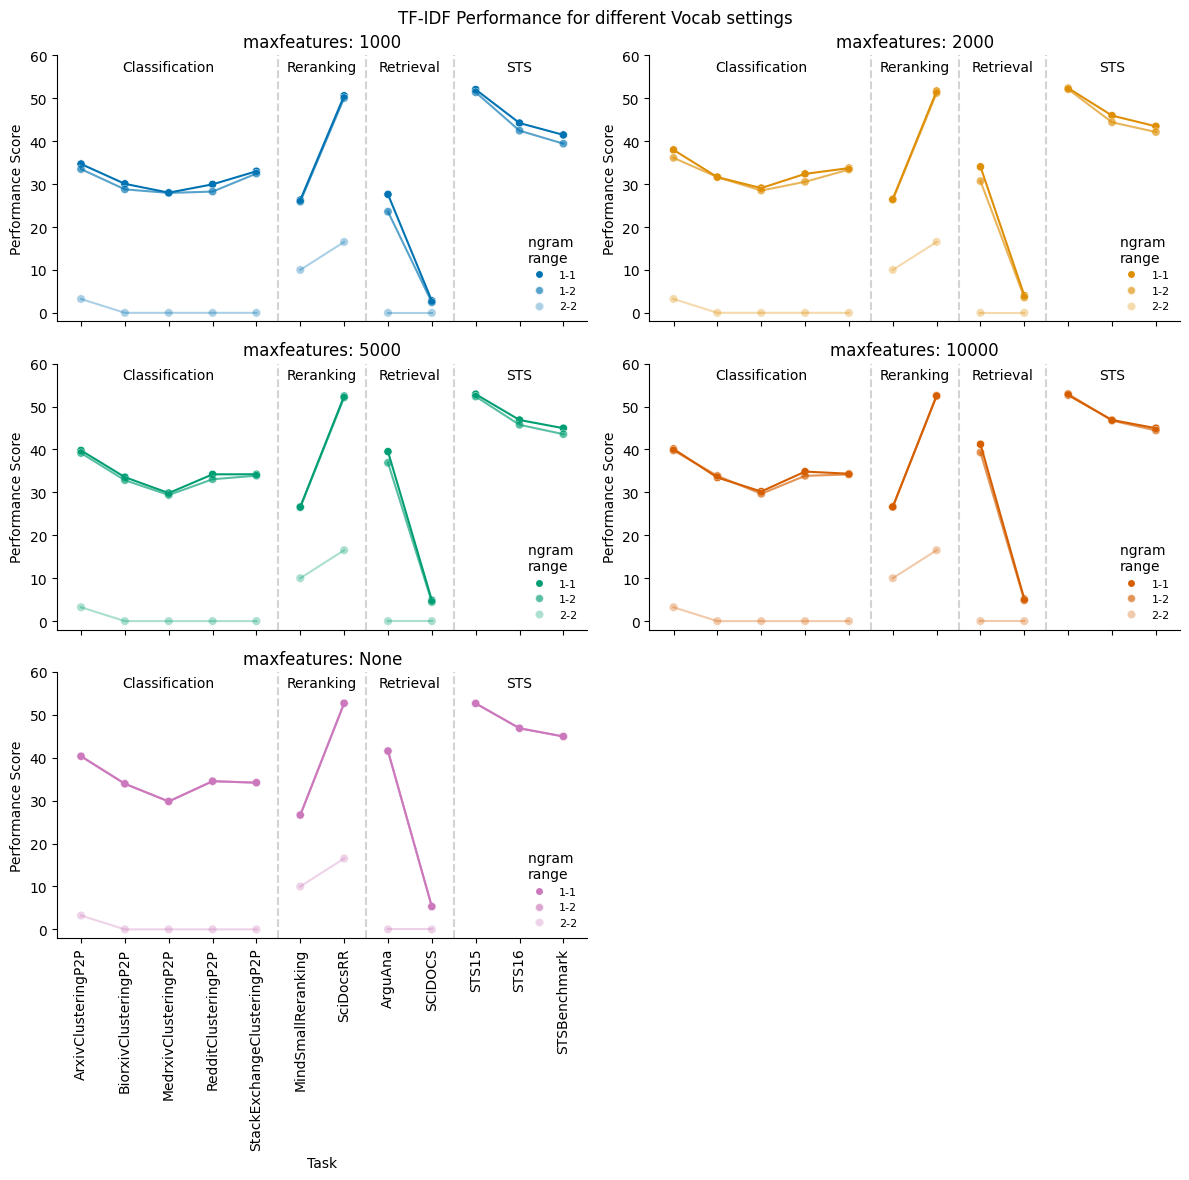

In [64]:
# plot comparing ngram ranges

fig, axs = plt.subplots(3,2, figsize=(12, 12))

# iterate through maxfeatures
k = 0
for i in range(3):
    for j in range(2):
        ax = axs[i,j]

        if i==2 and j==1:
            ax.axis("off")
        
        else:
            mf = maxfeatures[k]
            k +=1

            df_mf = df_melted[df_melted['maxfeatures'] == mf]
            for n in ngram:
                df_ngram = df_mf[df_mf['ngram'] == n]
                sns.scatterplot(data=df_ngram, x='x_pos', y='score', hue='maxfeatures', 
                                palette=colors_dict, alpha=opacity_dict[n], ax=ax)

                # Draw lines connecting tasks within the same category for each model
                for model in df_ngram['version'].unique():
                    subset = df_ngram[df_mf['version'] == model]
                    for category in subset['task_types'].unique():
                        category_subset = subset[subset['task_types'] == category]
                        category_subset_sorted = category_subset.sort_values("x_pos")
                        sns.lineplot(data=category_subset_sorted, x='x_pos', y='score', hue='maxfeatures', 
                                    palette=colors_dict, alpha=opacity_dict[n], legend=False, ax=ax)
    
            # add task type text
            tasks = ["Classification", "Reranking", "Retrieval", "STS"]
            placement = [3, 6.5, 8.5, 11]
            for task, place in zip(tasks, placement):
                ax.text(place, 59, task, horizontalalignment = "center", verticalalignment = "top")
            # task type boundaries
            boundaries = [0.5, 5.5, 7.5, 9.5, 12.5]
            for b in range(1, len(boundaries)-1):
                ax.axvline(boundaries[b], linestyle = "dashed", color = "lightgrey")
    
            # design stuff
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

            ax.set_ylabel('Performance Score')
            ax.set_ylim(-2, 60)

            legend_elements = [Line2D([0], [0], marker="o", color="w", markerfacecolor=colors_dict[mf], label=n, alpha=opacity_dict[n]) for n in ngram]
            ax.legend(handles=legend_elements, frameon=False, title="ngram \nrange", prop={'size': 8}, loc="lower right")

            ax.set_title(f"maxfeatures: {mf}")

            if (i==2 and j==0): #lowest plot
                ax.set_xticks(range(1,13), labels=list(task_order.keys()), rotation=90)
                ax.set_xlabel('Task')
            else:
                ax.set_xticks(range(1,13), labels=[])
                ax.set_xlabel(None)


plt.suptitle('TF-IDF Performance for different Vocab settings')
plt.tight_layout()
plt.savefig("../img/tfidf_vocab_ngram.png")

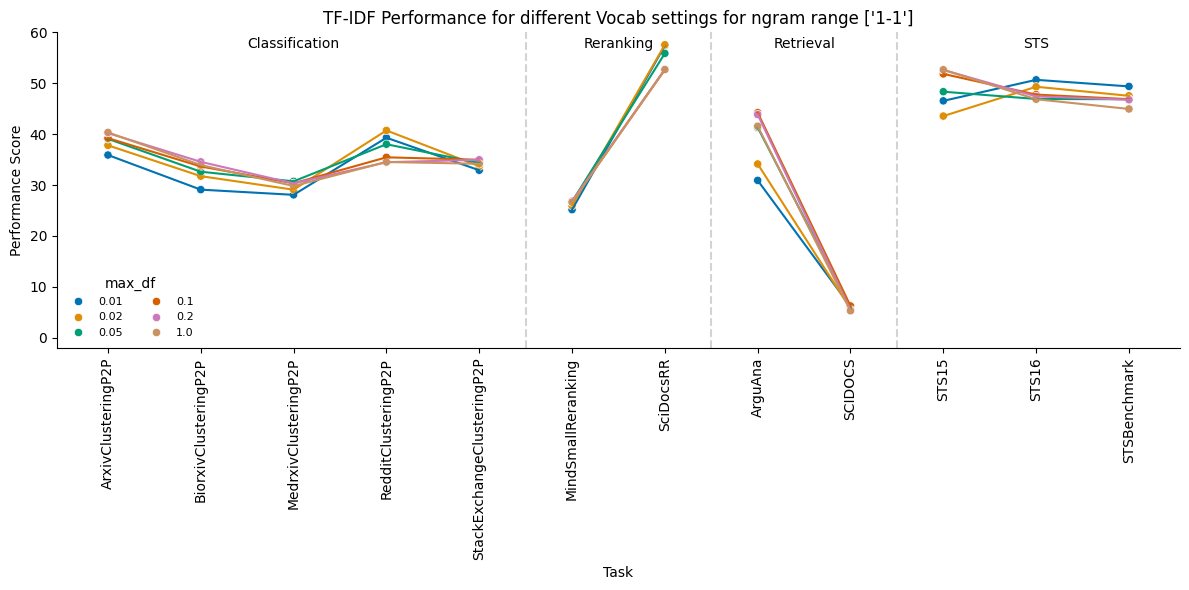

In [19]:
# plot for varying maxdf
fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(data=df_melted, x='x_pos', y='score', hue='maxdf', palette=colors_dict_maxdf)

# Draw lines connecting tasks within the same category for each model
for model in df_melted['version'].unique():
    subset = df_melted[df_melted['version'] == model]
    for category in subset['task_types'].unique():
        category_subset = subset[subset['task_types'] == category]
        category_subset_sorted = category_subset.sort_values("x_pos")
        sns.lineplot(data=category_subset_sorted, x='x_pos', y='score', hue='maxdf', palette=colors_dict_maxdf, legend=False)

# add task type text
tasks = ["Classification", "Reranking", "Retrieval", "STS"]
placement = [3, 6.5, 8.5, 11]
for task, place in zip(tasks, placement):
    plt.text(place, 59, task, horizontalalignment = "center", verticalalignment = "top")
# task type boundaries
boundaries = [0.5, 5.5, 7.5, 9.5, 12.5]
for j in range(1, len(boundaries)-1):
    plt.axvline(boundaries[j], linestyle = "dashed", color = "lightgrey")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend(title="max_df", frameon=False, prop={'size': 8}, ncol=2, loc="lower left")
plt.title(f'TF-IDF Performance for different Vocab settings for ngram range {ngram}')
plt.xlabel('Task')
plt.ylabel('Performance Score')
plt.ylim(-2,60)
plt.xticks(range(1,13), labels=list(task_order.keys()), rotation=90)
plt.tight_layout()
plt.savefig("../img/tfidf_vocab_maxdf_single.png")

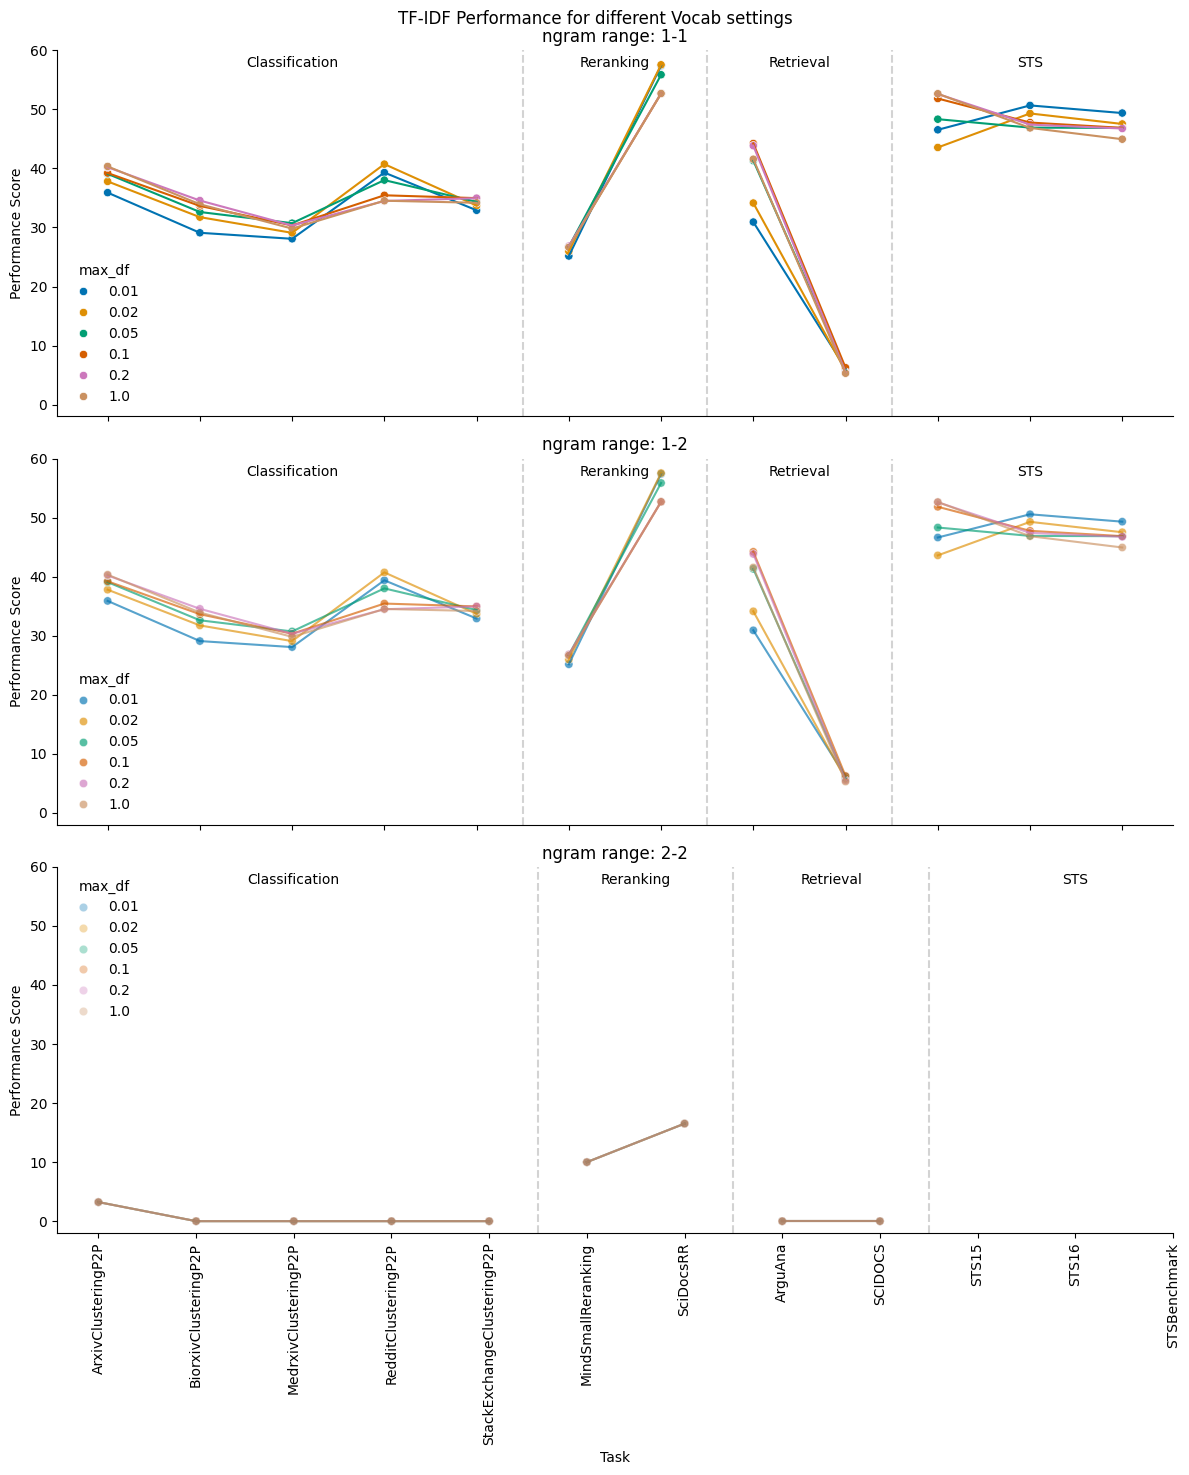

In [63]:
# varying maxdf, multiple plots

fig, axs = plt.subplots(len(ngram), figsize=(12, len(ngram)*5))

# iterate through ngram levels
for i, n in enumerate(ngram):
    if len(ngram) == 1:
        ax = axs
    else:
        ax = axs[i]
    df_ngram = df_melted[df_melted['ngram'] == n]
    sns.scatterplot(data=df_ngram, x='x_pos', y='score', hue='maxdf', 
                    palette=colors_dict_maxdf, alpha=opacity_dict[n], ax=ax)

    # Draw lines connecting tasks within the same category for each model
    for model in df_ngram['version'].unique():
        subset = df_ngram[df_ngram['version'] == model]
        for category in subset['task_types'].unique():
            category_subset = subset[subset['task_types'] == category]
            category_subset_sorted = category_subset.sort_values("x_pos")
            sns.lineplot(data=category_subset_sorted, x='x_pos', y='score', hue='maxdf', 
                         palette=colors_dict_maxdf, alpha=opacity_dict[n], legend=False, ax=ax)
    
    # add task type text
    tasks = ["Classification", "Reranking", "Retrieval", "STS"]
    placement = [3, 6.5, 8.5, 11]
    for task, place in zip(tasks, placement):
        ax.text(place, 59, task, horizontalalignment = "center", verticalalignment = "top")
    # task type boundaries
    boundaries = [0.5, 5.5, 7.5, 9.5, 12.5]
    for j in range(1, len(boundaries)-1):
        ax.axvline(boundaries[j], linestyle = "dashed", color = "lightgrey")
    
    # design stuff
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.legend(title="max_df", frameon=False)
    ax.set_ylabel('Performance Score')
    ax.set_ylim(-2, 60)

    ax.set_title(f"ngram range: {n}")

    if i == len(ngram)-1: #lowest plot
        ax.set_xticks(range(1,13), labels=list(task_order.keys()), rotation=90)
        ax.set_xlabel('Task')
    else:
        ax.set_xticks(range(1,13), labels=[])
        ax.set_xlabel(None)



plt.suptitle('TF-IDF Performance for different Vocab settings')
plt.tight_layout()
plt.savefig("../img/tfidf_vocab_maxdf.png")

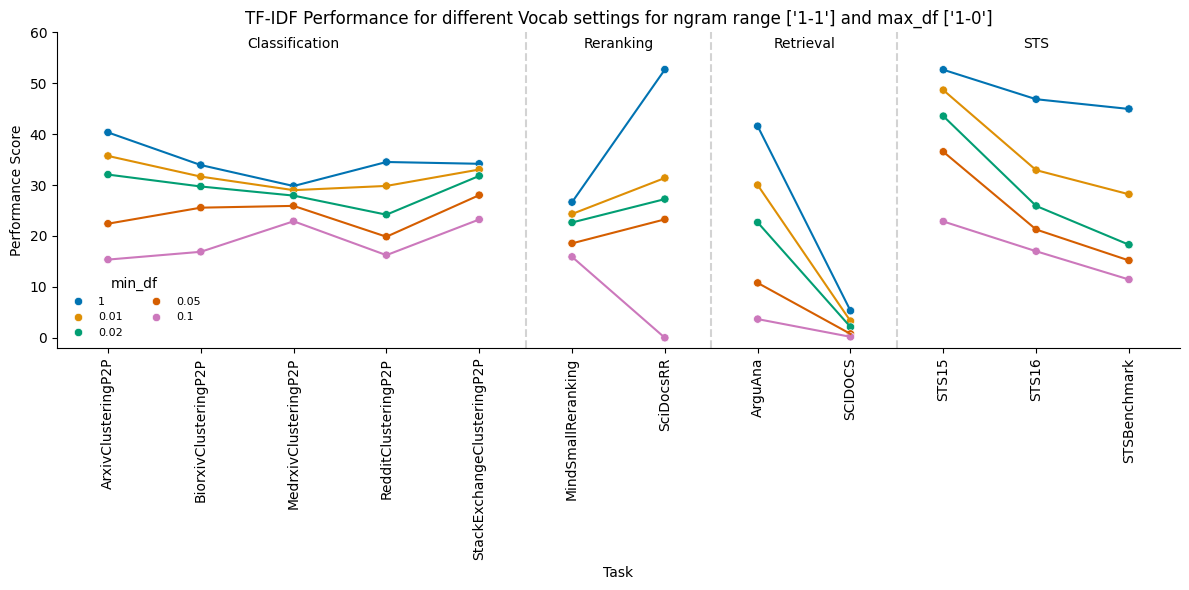

In [26]:
# plot for varying mindf
fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(data=df_melted, x='x_pos', y='score', hue='mindf', palette=colors_dict_mindf)

# Draw lines connecting tasks within the same category for each model
for model in df_melted['version'].unique():
    subset = df_melted[df_melted['version'] == model]
    for category in subset['task_types'].unique():
        category_subset = subset[subset['task_types'] == category]
        category_subset_sorted = category_subset.sort_values("x_pos")
        sns.lineplot(data=category_subset_sorted, x='x_pos', y='score', hue='mindf', palette=colors_dict_mindf, legend=False)

# add task type text
tasks = ["Classification", "Reranking", "Retrieval", "STS"]
placement = [3, 6.5, 8.5, 11]
for task, place in zip(tasks, placement):
    plt.text(place, 59, task, horizontalalignment = "center", verticalalignment = "top")
# task type boundaries
boundaries = [0.5, 5.5, 7.5, 9.5, 12.5]
for j in range(1, len(boundaries)-1):
    plt.axvline(boundaries[j], linestyle = "dashed", color = "lightgrey")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend(title="min_df", frameon=False, ncol=2, prop={'size': 8}, loc="lower left")
plt.title(f'TF-IDF Performance for different Vocab settings for ngram range {ngram} and max_df {maxdf}')
plt.xlabel('Task')
plt.ylabel('Performance Score')
plt.ylim(-2,60)
plt.xticks(range(1,13), labels=list(task_order.keys()), rotation=90)
plt.tight_layout()
plt.savefig("../img/tfidf_vocab_mindf_single.png")

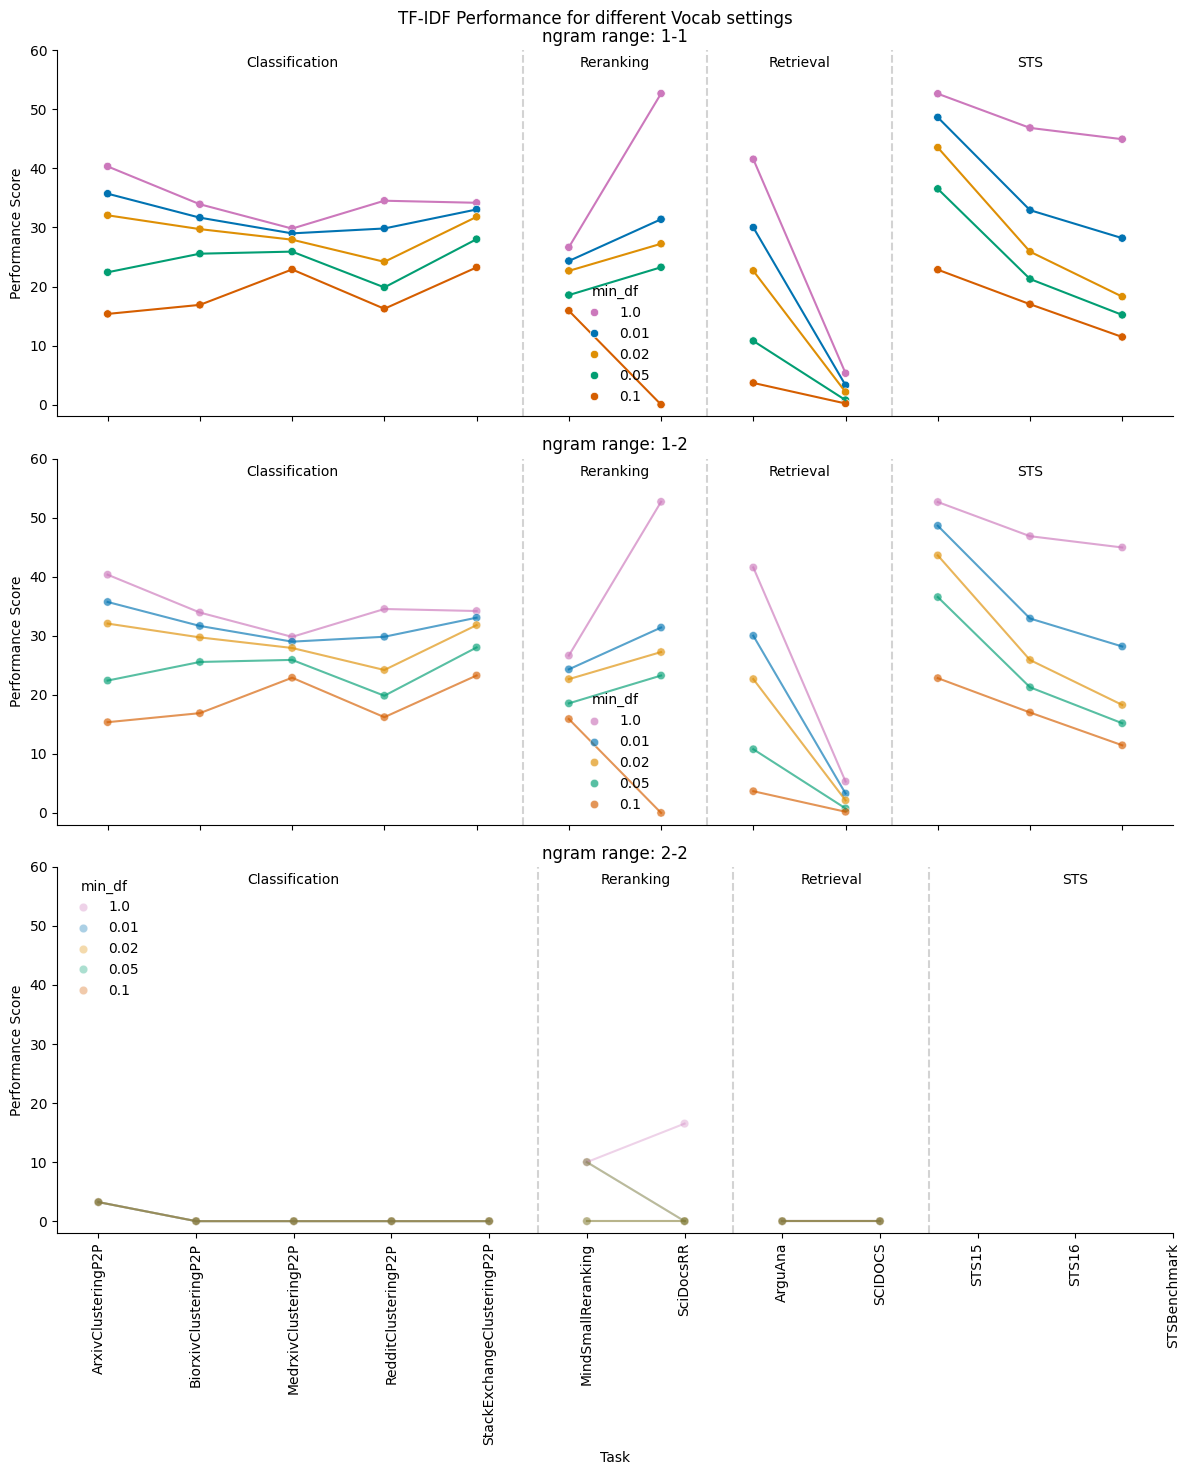

In [85]:
# varying mindf, multiple plots

fig, axs = plt.subplots(len(ngram), figsize=(12, len(ngram)*5))

# iterate through ngram levels
for i, n in enumerate(ngram):
    if len(ngram) == 1:
        ax = axs
    else:
        ax = axs[i]
    df_ngram = df_melted[df_melted['ngram'] == n]
    sns.scatterplot(data=df_ngram, x='x_pos', y='score', hue='mindf', 
                    palette=colors_dict_mindf, alpha=opacity_dict[n], ax=ax)

    # Draw lines connecting tasks within the same category for each model
    for model in df_ngram['version'].unique():
        subset = df_ngram[df_ngram['version'] == model]
        for category in subset['task_types'].unique():
            category_subset = subset[subset['task_types'] == category]
            category_subset_sorted = category_subset.sort_values("x_pos")
            sns.lineplot(data=category_subset_sorted, x='x_pos', y='score', hue='mindf', 
                         palette=colors_dict_mindf, alpha=opacity_dict[n], legend=False, ax=ax)
    
    # add task type text
    tasks = ["Classification", "Reranking", "Retrieval", "STS"]
    placement = [3, 6.5, 8.5, 11]
    for task, place in zip(tasks, placement):
        ax.text(place, 59, task, horizontalalignment = "center", verticalalignment = "top")
    # task type boundaries
    boundaries = [0.5, 5.5, 7.5, 9.5, 12.5]
    for j in range(1, len(boundaries)-1):
        ax.axvline(boundaries[j], linestyle = "dashed", color = "lightgrey")
    
    # design stuff
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.legend(title="min_df", frameon=False)
    ax.set_ylabel('Performance Score')
    ax.set_ylim(-2, 60)

    ax.set_title(f"ngram range: {n}")

    if i == len(ngram)-1: #lowest plot
        ax.set_xticks(range(1,13), labels=list(task_order.keys()), rotation=90)
        ax.set_xlabel('Task')
    else:
        ax.set_xticks(range(1,13), labels=[])
        ax.set_xlabel(None)



plt.suptitle('TF-IDF Performance for different Vocab settings')
plt.tight_layout()
plt.savefig("../img/tfidf_vocab_mindf.png")